# Test Cuantización - Fingers Dataset

## PARTE 1: PREPARACIÓN (ejecutar una sola vez)
Este notebook se divide en dos partes principales:

1. **PREPARATION PART**: Extrae features, entrena modelos base, genera datos cuantizados, y guarda todos los artefactos (modelos, CSV, escalares normalizador).

2. **EVALUATION PART**: Carga los artefactos preparados y realiza evaluación, comparación de errores, y análisis. Se puede modificar y ejecutar múltiples veces sin recalcular nada.

Área: 3740.0
Perímetro: 343.49747468305833
Excentricidad: 0.05970895058121077
Solidez: 0.9130859375
Bounding box: (0, 0, 64, 64)
Centroide: (np.float64(31.470320855614972), np.float64(31.55133689839572))
----------------------------------------
Área: 34.0
Perímetro: 23.485281374238568
Excentricidad: 0.9413057228483238
Solidez: 0.723404255319149
Bounding box: (30, 26, 36, 38)
Centroide: (np.float64(32.529411764705884), np.float64(31.058823529411764))
----------------------------------------


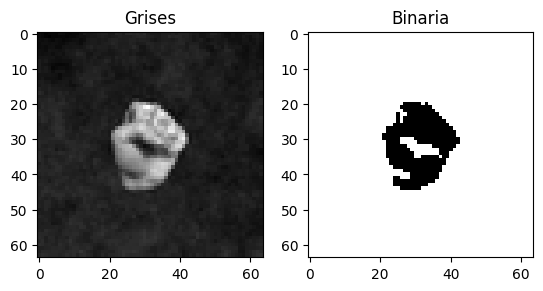

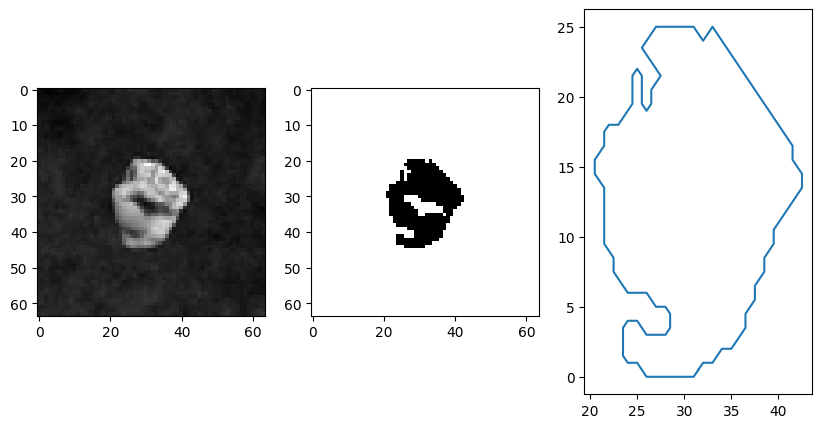

In [22]:
## Visualización Inicial (Referencia)

# Mostrar características extraíbles de una imagen del dataset
FUENTES_DIR = '../Fuentes'         # carpeta donde se encuentran archivos .py auxiliares
DATOS_DIR   = '../Imagenes/Fingers/' # carpeta donde se encuentran los datasets
import os, glob, math, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.filters import threshold_otsu
from skimage.morphology import closing, footprint_rectangle
from skimage.segmentation import clear_border
from skimage.measure import regionprops, label, find_contours

img = io.imread(DATOS_DIR + "samples/0L.png")
# Si la imagen tiene 4 canales (RGBA), convertir a RGB antes de pasar a escala de grises
if img.shape[-1] == 4:
    img_rgb = img[..., :3]
    gray = color.rgb2gray(img_rgb)
else:
    gray = color.rgb2gray(img) if len(img.shape) == 3 else img

# binarización (umbral automático Otsu)
thresh = threshold_otsu(gray)
binary = gray < thresh  # mano en blanco (1), fondo negro (0)

# etiquetar regiones
label_img = label(binary)

# extraer propiedades
props = regionprops(label_img)

# mostrar algunas propiedades de la primera región
for prop in props:
    print(f"Área: {prop.area}")
    print(f"Perímetro: {prop.perimeter}")
    print(f"Excentricidad: {prop.eccentricity}")
    print(f"Solidez: {prop.solidity}")
    print(f"Bounding box: {prop.bbox}")
    print(f"Centroide: {prop.centroid}")
    print("-" * 40)

# graficar
plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Grises")

plt.subplot(1,2,2)
plt.imshow(binary, cmap="gray")
plt.title("Binaria")
plt.show()

fig, axs = plt.subplots(1,3, figsize=(10,5))
axs[0].imshow(gray, cmap='gray')
axs[1].imshow(binary, cmap='gray')

contour = find_contours(binary, 0.5)[0]
y, x = contour.T

axs[2].plot(x, y.max()-y)

---
## INICIO: PART 1 - PREPARATION
---

Ejecuta esta sección una sola vez. Genera todos los artefactos necesarios (modelos, datos, escalares) que serán usados en la PART 2 (Evaluación).

**Outputs generados:**
- Modelos: `fingers_model_no_quantization.h5`, `fingers_model_q_signed_symmetric_per_layer.h5`, `fingers_model_q_signed_symmetric_per_neuron.h5` (+ TFLite)
- Datos: CSVs cuantizados y no-cuantizados
- Escalares: `normalizer.pkl`

---
# PART 1: PREPARATION
---

## 1. Feature Extraction from Images

Convierte las imágenes en las carpetas **"test"** y **"train"** del dataset **"Fingers"** en dos archivos (uno por carpeta) separados por comas (csv). De todas las características que provee **regionprops**, tienen potencial aquellas que son independientes o se pueden independizar de las unidades (píxeles). Algunas de estas características pueden ser:

- **filled_area:** cantidad de píxeles que contiene región (podría interpretarse como píxeles cuadrados).
- **major_axis_length:** longitud (en píxeles) del eje mayor de la elipse que mejor se ajusta a la región.
- **minor_axis_length:** longitud (en píxeles) del eje menor de la elipse que mejor se ajusta a la región.
- **perimeter:** cantidad de píxeles que forman el contorne de la región.
- **eccentricity:** excentricidad de la elipse de mejor ajuste, cerca de 0 es un círculo, mientras que cerca de 1 es una elipse más "larga".
- **solidity:** razón entre la cantidad de píxeles de la región original y de la región convexa. Para generar una región convexa se completan los pixeles de forma de eliminar regiones cóncavas de una figura. La región convexa de una estrella de 5 puntas se convertirá en un pentágono al completarla.
- **extent:** razón entre pixeles de la región original y el rectángulo que la contiene (bounding box).

In [23]:
import os, glob, math, warnings
import pandas as pd
import numpy as np
from skimage import io
from skimage.filters import threshold_otsu
from skimage.morphology import closing, footprint_rectangle
from skimage.segmentation import clear_border
from skimage.measure import regionprops, label

warnings.filterwarnings("ignore", category=FutureWarning)  # silencia warnings 

from skimage.morphology import footprint_rectangle

def extraer_caracteristicas(imagen):
    umbral = threshold_otsu(imagen)
    imagen_bn = (imagen > umbral)*1
    imagen_bn = closing(imagen_bn, footprint_rectangle((3, 3)))  
    imagen_lista = clear_border(imagen_bn)
    regiones = regionprops(label(imagen_lista))
    return (regiones[0], imagen_lista)


def convertir_dataset(dir_orig, dir_arch_dest):
    columnas = ['AreaNorm', 'PerimNorm', 'RazonEjes', 'Excentricidad', 
                'Solidez', 'Extension', 'CantDedos']

    archivos = glob.glob(os.path.join(dir_orig, '**/*.png'), recursive=True)
    data = []

    total = len(archivos)
    for nro, archivo in enumerate(archivos, start=1):
        if nro % 200 == 0 or nro == total:  # imprime cada 200 imgs, no en todas
            print(f"\rProcesando {nro}/{total} imágenes ({100*nro/total:.2f}%)", end="")

        imagen = io.imread(archivo)
        cant_dedos = int(os.path.basename(os.path.dirname(archivo)))  # nombre carpeta = etiqueta

        props, imagen_bn = extraer_caracteristicas(imagen)

        area = props.filled_area
        ej_mayor = props.major_axis_length
        ej_menor = props.minor_axis_length
        perim = props.perimeter
        excentr = props.eccentricity
        solidez = props.solidity
        extension = props.extent

        # normalización
        area = area / (ej_mayor * ej_menor)
        perim = perim / math.sqrt(ej_mayor * ej_menor)
        razon_ej = ej_menor / ej_mayor

        data.append([area, perim, razon_ej, excentr, solidez, extension, cant_dedos])

    df = pd.DataFrame(columns=columnas, data=data)
    df.to_csv(dir_arch_dest, index=False)
    print(f"\n✅ Guardado en {dir_arch_dest}")

# Uso -> guarda en DeepLearning/Data_Sets/p4/
base_out = "../Data_Sets"

convertir_dataset("../Imagenes/Fingers/train", os.path.join(base_out, "fingers_train.csv"))
convertir_dataset("../Imagenes/Fingers/test",  os.path.join(base_out, "fingers_test.csv"))

Procesando 17999/17999 imágenes (100.00%)
✅ Guardado en ../Data_Sets/fingers_train.csv
Procesando 3600/3600 imágenes (100.00%)
✅ Guardado en ../Data_Sets/fingers_test.csv


## 2. Data Loading, Normalization & Baseline Model Training

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib  # para guardar el normalizer
import pickle

from sklearn import preprocessing, metrics, model_selection

from sklearn.model_selection import cross_val_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
import seaborn as sns
DATOS_DIR   = '../Data_Sets/' # carpeta donde se encuentran los datasets
# CARGA DE DATASET
nom_archivo = DATOS_DIR + 'fingers_train.csv'
datos = pd.read_csv(nom_archivo)


# separa características y clase
X = np.array(datos.iloc[:, :-1])
Y = np.array(datos.iloc[:, -1])
nomClases = datos.iloc[:, -1].value_counts()

# Target codificado como one-hot
encoder = preprocessing.LabelEncoder()
Y_nro = encoder.fit_transform(Y)
Y_bin= to_categorical(Y_nro)

# CONJUNTOS DE ENTRENAMIENTO Y VALIDACION
X_train, X_val, Y_train, Y_val = model_selection.train_test_split( \
                                         X, Y_bin, test_size=0.20, random_state=42)

normalizador = preprocessing.StandardScaler()
X_train = normalizador.fit_transform(X_train)
X_val = normalizador.transform(X_val)

# Guardar normalizer para uso en evaluación
joblib.dump(normalizador, os.path.join(DATOS_DIR, 'normalizer.pkl'))
print(f"✅ Normalizer guardado en {os.path.join(DATOS_DIR, 'normalizer.pkl')}")

datos

✅ Normalizer guardado en ../Data_Sets/normalizer.pkl


,AreaNorm,PerimNorm,RazonEjes,Excentricidad,Solidez,Extension,CantDedos
0,0.772097,3.455084,0.679345,0.733819,0.932500,0.690741,0
1,0.747383,3.474195,0.642108,0.766614,0.922849,0.691111,0
2,0.734556,4.203402,0.766965,0.641689,0.892857,0.636364,0
3,0.768645,3.446018,0.730245,0.683185,0.925414,0.670000,0
4,0.774000,3.365307,0.730927,0.682455,0.940510,0.728070,0
...,...,...,...,...,...,...,...
17994,0.551767,5.648539,0.633040,0.774119,0.576408,0.393773,5
17995,0.576778,5.770199,0.699539,0.714595,0.600000,0.371512,5
17996,0.538463,6.011802,0.712541,0.701631,0.555088,0.365854,5
17997,0.605275,5.455247,0.732710,0.680541,0.613725,0.382173,5


### 3a. Baseline Model Architecture & Training

In [25]:
ENTRADAS = X_train.shape[1]
SALIDAS = Y_train.shape[1]
OCULTAS = 8
EPOCAS = 200
LOTES = 32
PACIENCIA = 5
ACTIVACION = 'tanh'
OPTIMIZADOR = 'adam'


# %% CONSTRUCCION DEL MODELO
model = Sequential()
model.add(Dense(OCULTAS, input_shape=[ENTRADAS], activation=ACTIVACION))
model.add(Dense(SALIDAS, activation='softmax'))
model.summary()  #-- muestra la cantidad de parámetros de la red


model.compile(optimizer=OPTIMIZADOR, loss='categorical_crossentropy', metrics=['accuracy'])

# %% ENTRENAMIENTO

# parada temprana para evitar el sobreajuste
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=PACIENCIA)

# entrena el modelo y guarda la historia del progreso
history = model.fit(X_train,Y_train, epochs=EPOCAS, batch_size=LOTES, validation_data = (X_val, Y_val), callbacks=[early_stop])

#Guarda el modelo entrenado
model.save('../Models/fingers_model_no_quantization.h5')

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │            54 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110 (440.00 B)

 Trainable params: 110 (440.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6266 - loss: 1.1469 - val_accuracy: 0.7747 - val_loss: 0.7575
Epoch 2/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 834us/step - accuracy: 0.8320 - loss: 0.6029 - val_accuracy: 0.8664 - val_loss: 0.4977
Epoch 3/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - accuracy: 0.9110 - loss: 0.4296 - val_accuracy: 0.9328 - val_loss: 0.3735
Epoch 4/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step - accuracy: 0.9391 - loss: 0.3318 - val_accuracy: 0.9428 - val_loss: 0.2947
Epoch 5/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - accuracy: 0.9462 - loss: 0.2666 - val_accuracy: 0.9506 - val_loss: 0.2403
Epoch 6/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step - accuracy: 0.9531 - loss: 0.2220 - val_accuracy: 0.9556 - val_loss: 0.2009
Epoch 7/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step - accuracy: 0.9577 - loss: 0.1896 - val_accuracy: 0.9581 - val_loss: 0.1718
Epoch 8/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - accuracy: 0.9610 - loss: 0.1

## 3b. Quantization & Weight/I/O Data Processing

Cuantización simétrica con signo: se cuantizan los pesos del modelo usando int8 (dos versiones: por capa, y por neurona). Se cuantizan también las entradas y salidas de los modelos, generando múltiples pipelines (I/O dequantized vs I/O quantized). Se guardan todos los modelos y datos para la fase de evaluación.

In [40]:
import os
import io
import warnings
import logging
import contextlib

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import tensorflow as tf
from absl import logging as absl_logging

tf.get_logger().setLevel('ERROR')
logging.getLogger('tensorflow').setLevel(logging.ERROR)
absl_logging.set_verbosity(absl_logging.ERROR)


# Funciones auxiliares para cuantización

def quantize_symmetric_signed(x, bits=8, axis=None, eps=1e-12):
    """Cuantización simétrica con signo a int8"""
    qmax = (2 ** (bits - 1)) - 1
    if axis is None:
        max_abs = np.max(np.abs(x))
    else:
        max_abs = np.max(np.abs(x), axis=axis, keepdims=True)
    scale = np.where(max_abs < eps, 1.0, max_abs / qmax)
    q = np.round(x / scale)
    q = np.clip(q, -qmax, qmax).astype(np.int32)
    dq = (q.astype(np.float32) * scale).astype(np.float32)
    return q, dq, scale


def quantize_dense_weights_symmetric(model, bits=8, mode='per_layer'):
    """Crea modelo con pesos cuantizados y luego dequantizados"""
    q_model = tf.keras.models.clone_model(model)
    q_model.build(model.input_shape)
    new_weights = []
    for w in model.get_weights():
        if mode == 'per_layer':
            _, w_dq, _ = quantize_symmetric_signed(w, bits=bits, axis=None)
        elif mode == 'per_neuron':
            if w.ndim == 2:
                _, w_dq, _ = quantize_symmetric_signed(w, bits=bits, axis=0)
            else:
                _, w_dq, _ = quantize_symmetric_signed(w, bits=bits, axis=0)
        else:
            raise ValueError("mode debe ser 'per_layer' o 'per_neuron'")
        new_weights.append(w_dq)
    q_model.set_weights(new_weights)
    q_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return q_model


def export_full_int8_tflite(model_to_convert, output_path, x_reference, max_samples=500):
    """Exporta modelo con cuantización int8 completa a TFLite"""
    converter = tf.lite.TFLiteConverter.from_keras_model(model_to_convert)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    x_reference = x_reference.astype(np.float32)

    def representative_dataset():
        n = min(max_samples, x_reference.shape[0])
        for i in range(n):
            yield [x_reference[i:i+1]]

    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    # Silencia output verboso
    stderr_fd = os.dup(2)
    devnull_fd = os.open(os.devnull, os.O_WRONLY)
    try:
        os.dup2(devnull_fd, 2)
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            tflite_model = converter.convert()
    finally:
        os.dup2(stderr_fd, 2)
        os.close(stderr_fd)
        os.close(devnull_fd)

    with open(output_path, 'wb') as f:
        f.write(tflite_model)


def quantize_csv_inputs_with_scale(src_csv, dst_csv, scaler, bits=8):
    """Cuantiza entradas CSV sobre features normalizadas y devuelve escala exacta."""
    df = pd.read_csv(src_csv)
    x_raw = df.iloc[:, :-1].to_numpy(dtype=np.float32)
    y = df.iloc[:, -1].to_numpy()

    # Los modelos fueron entrenados con entradas normalizadas
    x_norm = scaler.transform(x_raw)

    q_x, _, scale = quantize_symmetric_signed(x_norm, bits=bits, axis=0)

    out = pd.DataFrame(q_x, columns=df.columns[:-1])
    out[df.columns[-1]] = y
    out.to_csv(dst_csv, index=False)
    return scale.astype(np.float32), list(df.columns[:-1])


# Construcción de modelos cuantizados
DATOS_DIR = '../Data_Sets/'
MODELOS_DIR = '../Models/'
BASE_MODEL_PATH = MODELOS_DIR + 'fingers_model_no_quantization.h5'
BITS_W = 8
BITS_IO = 8

print('=' * 70)
print('CONSTRUCCIÓN DE MODELOS CUANTIZADOS')
print('=' * 70)

base_model = tf.keras.models.load_model(BASE_MODEL_PATH)
print('✅ Modelo base cargado\n')

# Cuantización de pesos por capa
print('Cuantizando pesos por capa...')
model_q_layer = quantize_dense_weights_symmetric(base_model, bits=BITS_W, mode='per_layer')
print('✅ Modelo per-layer completado\n')

# Cuantización de pesos por neurona
print('Cuantizando pesos por neurona...')
model_q_neuron = quantize_dense_weights_symmetric(base_model, bits=BITS_W, mode='per_neuron')
print('✅ Modelo per-neuron completado\n')

# Guardar modelos cuantizados en formato Keras H5
print('Guardando modelos H5 para carga rápida en evaluación...')
model_q_layer.save(MODELOS_DIR + 'fingers_model_q_signed_symmetric_per_layer.h5')
model_q_neuron.save(MODELOS_DIR + 'fingers_model_q_signed_symmetric_per_neuron.h5')
print('✅ Modelos H5 guardados:')
print('  - fingers_model_q_signed_symmetric_per_layer.h5')
print('  - fingers_model_q_signed_symmetric_per_neuron.h5\n')

# Guardar modelos int8 reales en TFLite
print('Exportando modelos int8 a TFLite...')
export_full_int8_tflite(model_q_layer, MODELOS_DIR + 'fingers_model_q_signed_symmetric_per_layer_int8.tflite', X_train)
export_full_int8_tflite(model_q_neuron, MODELOS_DIR + 'fingers_model_q_signed_symmetric_per_neuron_int8.tflite', X_train)
print('✅ Modelos TFLite guardados:')
print('  - fingers_model_q_signed_symmetric_per_layer_int8.tflite')
print('  - fingers_model_q_signed_symmetric_per_neuron_int8.tflite\n')

# Cuantizar datasets normalizados y guardar metadata exacta de escalas
print('Generando CSVs cuantizados normalizados + metadata exacta de cuantización...')
train_src = DATOS_DIR + 'fingers_train.csv'
train_dst = DATOS_DIR + 'fingers_train_quant8_signed_symmetric.csv'
test_src = DATOS_DIR + 'fingers_test.csv'
test_dst = DATOS_DIR + 'fingers_test_quant8_signed_symmetric.csv'

train_scale, feature_columns = quantize_csv_inputs_with_scale(train_src, train_dst, normalizador, bits=BITS_IO)
test_scale, _ = quantize_csv_inputs_with_scale(test_src, test_dst, normalizador, bits=BITS_IO)

meta_out = DATOS_DIR + 'quantization_metadata_signed_symmetric.npz'
np.savez(
    meta_out,
    bits_io=np.array([BITS_IO], dtype=np.int32),
    qmax=np.array([(2 ** (BITS_IO - 1)) - 1], dtype=np.int32),
    train_scale=train_scale,
    test_scale=test_scale,
    feature_columns=np.array(feature_columns, dtype=object),
    inputs_are_normalized=np.array([1], dtype=np.int32),
)
print('✅ CSVs cuantizados y metadata guardados:')
print('  - fingers_train_quant8_signed_symmetric.csv')
print('  - fingers_test_quant8_signed_symmetric.csv')
print('  - quantization_metadata_signed_symmetric.npz\n')

print('=' * 70)
print('✅ PARTE 1: PREPARACIÓN COMPLETADA')
print('=' * 70)
print('\nTodos los artefactos han sido guardados.')
print('Ahora puedes ejecutar PARTE 2: EVALUACIÓN\n')
print('=' * 70)

CONSTRUCCIÓN DE MODELOS CUANTIZADOS
✅ Modelo base cargado

Cuantizando pesos por capa...
✅ Modelo per-layer completado

Cuantizando pesos por neurona...
✅ Modelo per-neuron completado

Guardando modelos H5 para carga rápida en evaluación...
✅ Modelos H5 guardados:
  - fingers_model_q_signed_symmetric_per_layer.h5
  - fingers_model_q_signed_symmetric_per_neuron.h5

Exportando modelos int8 a TFLite...
✅ Modelos TFLite guardados:
  - fingers_model_q_signed_symmetric_per_layer_int8.tflite
  - fingers_model_q_signed_symmetric_per_neuron_int8.tflite

Generando CSVs cuantizados normalizados + metadata exacta de cuantización...
✅ CSVs cuantizados y metadata guardados:
  - fingers_train_quant8_signed_symmetric.csv
  - fingers_test_quant8_signed_symmetric.csv
  - quantization_metadata_signed_symmetric.npz

✅ PARTE 1: PREPARACIÓN COMPLETADA

Todos los artefactos han sido guardados.
Ahora puedes ejecutar PARTE 2: EVALUACIÓN



---
# PART 2: EVALUATION
---
## Load Pre-computed Artifacts

Carga todos los modelos, datos y artefactos generados en la parte de preparación. 

In [47]:
import os
import numpy as np
import pandas as pd
import joblib
import warnings
import logging

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import tensorflow as tf
from sklearn import metrics
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Silenciar logs
tf.get_logger().setLevel('ERROR')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# Paths
DATOS_DIR = '../Data_Sets/'
MODELOS_DIR = '../Models/'

# Load normalizer
normalizador = joblib.load(os.path.join(DATOS_DIR, 'normalizer.pkl'))

# Load models
base_model = tf.keras.models.load_model(os.path.join(MODELOS_DIR, 'fingers_model_no_quantization.h5'))

try:
    model_q_layer = tf.keras.models.load_model(os.path.join(MODELOS_DIR, 'fingers_model_q_signed_symmetric_per_layer.h5'))
    model_q_neuron = tf.keras.models.load_model(os.path.join(MODELOS_DIR, 'fingers_model_q_signed_symmetric_per_neuron.h5'))
    print('✅ Modelos cuantizados (H5) cargados')
    quantized_models_available = True
except FileNotFoundError:
    print('⚠️  Modelos H5 cuantizados no encontrados.')
    quantized_models_available = False

# Load exact quantization metadata from Preparation
meta_path = os.path.join(DATOS_DIR, 'quantization_metadata_signed_symmetric.npz')
if os.path.exists(meta_path):
    qmeta = np.load(meta_path, allow_pickle=True)
    train_input_scale_exact = qmeta['train_scale'].astype(np.float32)
    test_input_scale_exact = qmeta['test_scale'].astype(np.float32)
    bits_io_exact = int(qmeta['bits_io'][0])
    print('✅ Metadata de cuantización exacta cargada')
else:
    train_input_scale_exact = None
    test_input_scale_exact = None
    bits_io_exact = 8
    print('⚠️  Metadata de cuantización no encontrada (ejecuta PART 1).')

num_classes = int(base_model.output_shape[-1])

# Load float dataset (for baseline)
datos_float = pd.read_csv(os.path.join(DATOS_DIR, 'fingers_train.csv'))
X_float = np.array(datos_float.iloc[:, :-1], dtype=np.float32)
Y_float_raw = np.array(datos_float.iloc[:, -1]).astype(np.int32)
Y_float_bin = to_categorical(Y_float_raw, num_classes=num_classes)

X_train_float, X_val_float, Y_train_float, Y_val_float = train_test_split(
    X_float, Y_float_bin, test_size=0.20, random_state=42
)
# Reusa el normalizador entrenado en preparación (sin refit)
X_train_float = normalizador.transform(X_train_float)
X_val_float = normalizador.transform(X_val_float)

# Load pre-quantized datasets (no recalculation)
datos_q_train = pd.read_csv(os.path.join(DATOS_DIR, 'fingers_train_quant8_signed_symmetric.csv'))
datos_q_test = pd.read_csv(os.path.join(DATOS_DIR, 'fingers_test_quant8_signed_symmetric.csv'))

X_train_q = np.array(datos_q_train.iloc[:, :-1], dtype=np.float32)
Y_train_q_raw = np.array(datos_q_train.iloc[:, -1]).astype(np.int32)
X_test_q = np.array(datos_q_test.iloc[:, :-1], dtype=np.float32)
Y_test_q_raw = np.array(datos_q_test.iloc[:, -1]).astype(np.int32)

# Sin re-encoding: las etiquetas ya están como clases enteras
Y_train_q = to_categorical(Y_train_q_raw, num_classes=num_classes)
Y_test_q = to_categorical(Y_test_q_raw, num_classes=num_classes)


BITS_IO = bits_io_exact
BITS_W = 8


def dequantize_saved_inputs(X_q, scales):
    return X_q.astype(np.float32) * scales


def evaluate_baseline(model_to_eval, X_eval, Y_eval):
    y_pred_float = model_to_eval.predict(X_eval, verbose=0)
    y_true = np.argmax(Y_eval, axis=1)
    y_pred = np.argmax(y_pred_float, axis=1)
    return {
        'accuracy': metrics.accuracy_score(y_true, y_pred),
        'f1_macro': metrics.f1_score(y_true, y_pred, average='macro'),
        'report': metrics.classification_report(y_true, y_pred, digits=4),
        'cm': metrics.confusion_matrix(y_true, y_pred)
    }


def evaluate_pipeline_io_quantized_from_csv(model_to_eval, X_q_eval, Y_eval):
    y_pred_float = model_to_eval.predict(X_q_eval.astype(np.float32), verbose=0)
    y_true = np.argmax(Y_eval, axis=1)
    y_pred = np.argmax(y_pred_float, axis=1)
    return {
        'accuracy': metrics.accuracy_score(y_true, y_pred),
        'f1_macro': metrics.f1_score(y_true, y_pred, average='macro'),
        'report': metrics.classification_report(y_true, y_pred, digits=4),
        'cm': metrics.confusion_matrix(y_true, y_pred)
    }


def evaluate_pipeline_io_dequantized_from_csv(model_to_eval, X_q_eval, Y_eval, scales):
    X_dq_eval = dequantize_saved_inputs(X_q_eval, scales)
    y_pred_float = model_to_eval.predict(X_dq_eval.astype(np.float32), verbose=0)
    y_true = np.argmax(Y_eval, axis=1)
    y_pred = np.argmax(y_pred_float, axis=1)
    return {
        'accuracy': metrics.accuracy_score(y_true, y_pred),
        'f1_macro': metrics.f1_score(y_true, y_pred, average='macro'),
        'report': metrics.classification_report(y_true, y_pred, digits=4),
        'cm': metrics.confusion_matrix(y_true, y_pred)
    }


print('=' * 70)
print()

✅ Modelos cuantizados (H5) cargados
✅ Metadata de cuantización exacta cargada



In [51]:
# Análisis de error usando datos cuantizados ya guardados en CSV (sin requantizar)
from sklearn.metrics import mean_absolute_error, mean_squared_error


def get_outputs_io_dequantized_from_csv(model_to_eval, X_q_eval, scales):
    X_dq_eval = dequantize_saved_inputs(X_q_eval, scales)
    return model_to_eval.predict(X_dq_eval.astype(np.float32), verbose=0)


def get_outputs_io_quantized_from_csv(model_to_eval, X_q_eval):
    return model_to_eval.predict(X_q_eval.astype(np.float32), verbose=0)


def compare_quant_vs_dequant_outputs_from_csv(model_to_eval, X_q_eval, Y_eval, model_name, split_name, scales):
    y_dq = get_outputs_io_dequantized_from_csv(model_to_eval, X_q_eval, scales)
    y_q = get_outputs_io_quantized_from_csv(model_to_eval, X_q_eval)

    abs_err = np.abs(y_dq - y_q)

    pred_dq = np.argmax(y_dq, axis=1)
    pred_q = np.argmax(y_q, axis=1)
    y_true = np.argmax(Y_eval, axis=1)

    return {
        'Modelo': model_name,
        'Split': split_name,
        'MAE_salidas': mean_absolute_error(y_dq.reshape(-1), y_q.reshape(-1)),
        'MSE_salidas': mean_squared_error(y_dq.reshape(-1), y_q.reshape(-1)),
        'MaxAbsErr_salidas': abs_err.max(),
        'Top1_agreement_q_vs_dq': (pred_q == pred_dq).mean(),
        'Top1_disagreement_q_vs_dq': (pred_q != pred_dq).mean(),
        'Acc_dequantized': (pred_dq == y_true).mean(),
        'Acc_quantized': (pred_q == y_true).mean()
    }


print('=' * 70)
print('B. ANÁLISIS DE ERROR: Quantized vs Dequantized')
print('=' * 70)

if quantized_models_available and train_input_scale_exact is not None and test_input_scale_exact is not None:

    error_rows = []

    for model_name, model_ref in [
        ('Q (pesos por capa)', model_q_layer),
        ('Q (pesos por neurona)', model_q_neuron),
    ]:
        error_rows.append(compare_quant_vs_dequant_outputs_from_csv(model_ref, X_train_q, Y_train_q, model_name, 'TrainQ', train_input_scale_exact))
        error_rows.append(compare_quant_vs_dequant_outputs_from_csv(model_ref, X_test_q, Y_test_q, model_name, 'TestQ', test_input_scale_exact))

    error_comparison = pd.DataFrame(error_rows)
    pd.set_option('display.float_format', lambda x: f'{x:.8f}')

    print(error_comparison)

    error_out = '../Data_Sets/quantized_vs_dequantized_error_signed_symmetric.csv'
    error_comparison.to_csv(error_out, index=False)
    print(f'\n✅ Se guardó: {error_out}')
else:
    print('⚠️  Faltan modelos cuantizados o metadata exacta. Ejecuta PART 1 primero.')

B. ANÁLISIS DE ERROR: Quantized vs Dequantized
                  Modelo   Split  MAE_salidas  MSE_salidas  MaxAbsErr_salidas  \
0     Q (pesos por capa)  TrainQ   0.13519108   0.12786601         0.99999994   
1     Q (pesos por capa)   TestQ   0.13349116   0.12622677         0.99999994   
2  Q (pesos por neurona)  TrainQ   0.13450204   0.12721498         0.99999994   
3  Q (pesos por neurona)   TestQ   0.13289957   0.12574340         0.99999994   

   Top1_agreement_q_vs_dq  Top1_disagreement_q_vs_dq  Acc_dequantized  \
0              0.59675538                 0.40324462       0.99305517   
1              0.60250000                 0.39750000       0.99361111   
2              0.59825546                 0.40174454       0.99294405   
3              0.60416667                 0.39583333       0.99333333   

   Acc_quantized  
0     0.59542197  
1     0.59777778  
2     0.59708873  
3     0.59944444  

✅ Se guardó: ../Data_Sets/quantized_vs_dequantized_error_signed_symmetric.csv


### Resultados del analisis de error 

| Modelo                | Split  | MAE_salidas | MSE_salidas | MaxAbsErr_salidas | Top1_agreement | Top1_disagreement | Acc_dequantized | Acc_quantized |
|-----------------------|--------|------------:|------------:|------------------:|-----------------------:|--------------------------:|----------------:|--------------:|
| Q (pesos por capa)    | TrainQ |    0.135191 |    0.127866 |          1.000000 |               0.596755 |                  0.403245 |        0.993055 |      0.595422 |
| Q (pesos por capa)    | TestQ  |    0.133491 |    0.126227 |          1.000000 |               0.602500 |                  0.397500 |        0.993611 |      0.597778 |
| Q (pesos por neurona) | TrainQ |    0.134502 |    0.127215 |          1.000000 |               0.598255 |                  0.401745 |        0.992944 |      0.597089 |
| Q (pesos por neurona) | TestQ  |    0.132900 |    0.125743 |          1.000000 |               0.604167 |                  0.395833 |        0.993333 |      0.599444 |

### B. Quantized vs Dequantized 


In [53]:
# Evaluación completa: Baseline (float) + Cuantizados (desde CSV precomputado)
print('\n' + '=' * 70)
print('EVALUACIÓN DE MODELOS - PARTE 2')
print('=' * 70 + '\n')

if quantized_models_available and train_input_scale_exact is not None and test_input_scale_exact is not None:
    # Baseline con dataset float normalizado
    res_base_train = evaluate_baseline(base_model, X_train_float, Y_train_float)
    res_base_val = evaluate_baseline(base_model, X_val_float, Y_val_float)
    print(f"  Train Accuracy: {res_base_train['accuracy']:.6f}, F1 Macro: {res_base_train['f1_macro']:.6f}")
    print(f"  Val Accuracy:   {res_base_val['accuracy']:.6f}, F1 Macro: {res_base_val['f1_macro']:.6f}\n")

    # Evaluación usando CSV cuantizado ya generado
    res_q_layer_train_io_dq = evaluate_pipeline_io_dequantized_from_csv(model_q_layer, X_train_q, Y_train_q, train_input_scale_exact)
    res_q_layer_test_io_dq = evaluate_pipeline_io_dequantized_from_csv(model_q_layer, X_test_q, Y_test_q, test_input_scale_exact)
    res_q_neuron_train_io_dq = evaluate_pipeline_io_dequantized_from_csv(model_q_neuron, X_train_q, Y_train_q, train_input_scale_exact)
    res_q_neuron_test_io_dq = evaluate_pipeline_io_dequantized_from_csv(model_q_neuron, X_test_q, Y_test_q, test_input_scale_exact)

    res_q_layer_train_io_q = evaluate_pipeline_io_quantized_from_csv(model_q_layer, X_train_q, Y_train_q)
    res_q_layer_test_io_q = evaluate_pipeline_io_quantized_from_csv(model_q_layer, X_test_q, Y_test_q)
    res_q_neuron_train_io_q = evaluate_pipeline_io_quantized_from_csv(model_q_neuron, X_train_q, Y_train_q)
    res_q_neuron_test_io_q = evaluate_pipeline_io_quantized_from_csv(model_q_neuron, X_test_q, Y_test_q)

    comparison = pd.DataFrame([
        {'Modelo': 'Baseline', 'Pipeline': 'float', 'Split': 'Train', 'Accuracy': res_base_train['accuracy'], 'F1_macro': res_base_train['f1_macro']},
        {'Modelo': 'Baseline', 'Pipeline': 'float', 'Split': 'Val', 'Accuracy': res_base_val['accuracy'], 'F1_macro': res_base_val['f1_macro']},
        {'Modelo': 'Q per-layer', 'Pipeline': 'I/O dequant (from CSV)', 'Split': 'TrainQ', 'Accuracy': res_q_layer_train_io_dq['accuracy'], 'F1_macro': res_q_layer_train_io_dq['f1_macro']},
        {'Modelo': 'Q per-layer', 'Pipeline': 'I/O dequant (from CSV)', 'Split': 'TestQ', 'Accuracy': res_q_layer_test_io_dq['accuracy'], 'F1_macro': res_q_layer_test_io_dq['f1_macro']},
        {'Modelo': 'Q per-layer', 'Pipeline': 'I/O quant (from CSV)', 'Split': 'TrainQ', 'Accuracy': res_q_layer_train_io_q['accuracy'], 'F1_macro': res_q_layer_train_io_q['f1_macro']},
        {'Modelo': 'Q per-layer', 'Pipeline': 'I/O quant (from CSV)', 'Split': 'TestQ', 'Accuracy': res_q_layer_test_io_q['accuracy'], 'F1_macro': res_q_layer_test_io_q['f1_macro']},
        {'Modelo': 'Q per-neuron', 'Pipeline': 'I/O dequant (from CSV)', 'Split': 'TrainQ', 'Accuracy': res_q_neuron_train_io_dq['accuracy'], 'F1_macro': res_q_neuron_train_io_dq['f1_macro']},
        {'Modelo': 'Q per-neuron', 'Pipeline': 'I/O dequant (from CSV)', 'Split': 'TestQ', 'Accuracy': res_q_neuron_test_io_dq['accuracy'], 'F1_macro': res_q_neuron_test_io_dq['f1_macro']},
        {'Modelo': 'Q per-neuron', 'Pipeline': 'I/O quant (from CSV)', 'Split': 'TrainQ', 'Accuracy': res_q_neuron_train_io_q['accuracy'], 'F1_macro': res_q_neuron_train_io_q['f1_macro']},
        {'Modelo': 'Q per-neuron', 'Pipeline': 'I/O quant (from CSV)', 'Split': 'TestQ', 'Accuracy': res_q_neuron_test_io_q['accuracy'], 'F1_macro': res_q_neuron_test_io_q['f1_macro']},
    ])

    pd.set_option('display.float_format', lambda x: f'{x:.6f}')
    print('\n' + '=' * 70)
    print('TABLA COMPARATIVA: BASELINE + CUANTIZADOS')
    print('=' * 70)
    print(comparison.to_string(index=False))

    comparison.to_csv(DATOS_DIR + 'quantization_comparison_signed_symmetric.csv', index=False)
    print('\n✅ Guardado: quantization_comparison_signed_symmetric.csv\n')
else:
    print('⚠️  Faltan modelos cuantizados o metadata exacta. Ejecuta PART 1 primero.')


EVALUACIÓN DE MODELOS - PARTE 2

  Train Accuracy: 0.992916, F1 Macro: 0.992887
  Val Accuracy:   0.993889, F1 Macro: 0.994010


TABLA COMPARATIVA: BASELINE + CUANTIZADOS
      Modelo               Pipeline  Split  Accuracy  F1_macro
    Baseline                  float  Train  0.992916  0.992887
    Baseline                  float    Val  0.993889  0.994010
 Q per-layer I/O dequant (from CSV) TrainQ  0.993055  0.993060
 Q per-layer I/O dequant (from CSV)  TestQ  0.993611  0.993615
 Q per-layer   I/O quant (from CSV) TrainQ  0.595422  0.491095
 Q per-layer   I/O quant (from CSV)  TestQ  0.597778  0.491569
Q per-neuron I/O dequant (from CSV) TrainQ  0.992944  0.992949
Q per-neuron I/O dequant (from CSV)  TestQ  0.993333  0.993337
Q per-neuron   I/O quant (from CSV) TrainQ  0.597089  0.492589
Q per-neuron   I/O quant (from CSV)  TestQ  0.599444  0.493096

✅ Guardado: quantization_comparison_signed_symmetric.csv



## Explicación de las funciones de cuantización

### 1. `quantize_symmetric_signed(x, bits=8, axis=None, eps=1e-12)`

Convierte valores float a enteros simétricos con signo, luego los dequantiza de vuelta a float. Retorna tres cosas: enteros cuantizados `q`, floats dequantizados `dq`, y la escala.

**Matemática:**
- $q_{max} = 2^{(bits-1)} - 1$
- Para int8, $q_{max} = 127$, rango representable: $[-127, 127]$ (simétrico, sin usar -128)
- Escala: $scale = \frac{\max(|x|)}{q_{max}}$ (o por eje si se especifica)
- Cuantización: $q = round\left(\frac{x}{scale}\right)$ con $q \in [-q_{max}, q_{max}]$
- Dequantización: $dq = q \cdot scale$

**Paso a paso:**
1. Computa $q_{max}$ desde `bits`
2. Encuentra valor absoluto máximo globalmente (si `axis=None`) o por eje
3. Usa `eps` como guarda: si el máximo es muy pequeño, `scale = 1.0` para evitar división por cero
4. Redondea $x/scale$, clipea al rango simétrico, convierte a int32
5. Multiplica por scale para obtener `dq` en float32
6. Retorna `q`, `dq`, `scale`

---

### 2. `quantize_dense_weights_symmetric(model, bits=8, mode='per_layer')`

Crea una copia de un modelo Keras donde cada tensor de peso es reemplazado por su versión dequantizada. Dos modos: `per_layer` y `per_neuron`.

**Paso a paso:**
1. `clone_model` crea la misma arquitectura
2. `build(model.input_shape)` inicializa el modelo clonado
3. Itera sobre todos los tensores de `model.get_weights()`
4. Si `per_layer`: una escala para todo el tensor (axis=None)
5. Si `per_neuron`: 
   - Para kernels 2D de Dense (shape: entrada, salida), usa axis=0 para que cada neurona de salida/columna tenga su propia escala
   - Para tensores 1D como bias, también usa axis=0
6. Añade tensor dequantizado a `new_weights`
7. Asigna estos pesos al modelo clonado
8. Compila el modelo y lo retorna

**Nota importante:** El modelo retornado aún usa operaciones float en Keras. El efecto de cuantización se emula mediante pesos que fueron cuantizados y luego dequantizados.

---

### 3. `evaluate_pipeline_io_dequantized(model_to_eval, X_eval, Y_eval, bits_io=8)`

Evalúa un modelo después de cuantizar y luego dequantizar entradas y salidas. Simula ruido de cuantización manteniendo la ruta de inferencia en float.

**Paso a paso:**
1. Cuantiza $X_{eval}$ e inmediatamente dequantiza: $X_{qdq}$
2. Predice con el modelo en $X_{qdq}$
3. Cuantiza y dequantiza predicciones a $y_{pred-qdq}$
4. Convierte etiquetas one-hot a IDs de clase vía argmax
5. Convierte predicciones a IDs de clase vía argmax
6. Calcula accuracy, F1 macro, reporte de clasificación, matriz de confusión
7. Retorna estos métricas en un diccionario

**Nota:** Este es el camino más cercano al comportamiento de "fake quantization" (inferencia float con efectos de cuantización alrededor).

---

### 4. `evaluate_pipeline_io_quantized(model_to_eval, X_eval, Y_eval, bits_io=8)`

Evalúa con entradas similares a enteros cuantizados y salidas cuantizadas para decisión. Aún usa inferencia float internamente porque el modelo Keras espera tensores float.

**Paso a paso:**
1. Cuantiza entradas a $q_x$
2. Convierte $q_x$ a float32 y alimenta el modelo
3. Cuantiza salidas del modelo a $q_y$ (sin dequantizar para clasificación)
4. Aplica argmax en $q_y$ (convertido a float32) para clase predicha
5. Calcula el mismo diccionario de métricas que arriba

**Nota:** No es inferencia entera verdadera; datos con valores enteros pasan por operaciones Keras en float.

---

### 5. `evaluate_baseline(model_to_eval, X_eval, Y_eval)`

Evaluación estándar en float sin cuantización.

**Paso a paso:**
1. Predice directamente en $X_{eval}$
2. Argmax sobre etiquetas verdaderas y probabilidades predichas
3. Calcula y retorna el mismo diccionario de métricas

**Propósito:** Referencia para comparar variantes cuantizadas contra el comportamiento del modelo original.

---

### 6. `export_full_int8_tflite(model_to_convert, output_path, x_reference, max_samples=500)`

Convierte un modelo Keras a modelo TFLite completamente cuantizado int8 y lo escribe a disco.

**Paso a paso:**
1. Crea conversor desde modelo Keras
2. Habilita optimización por defecto
3. Convierte datos de referencia a float32
4. Construye generador de dataset representativo desde hasta `max_samples` muestras
5. Asigna `representative_dataset` para que el conversor calibre rangos de activaciones
6. Fuerza operaciones solo int8:
   - `supported_ops = TFLITE_BUILTINS_INT8`
   - `inference_input_type = int8`
   - `inference_output_type = int8`
7. Redirige stderr/stdout temporalmente para suprimir logs del conversor
8. Ejecuta `converter.convert()`
9. Restaura stderr y cierra file descriptors seguramente en `finally`
10. Escribe bytes binarios .tflite a `output_path`

**Nota importante:** Esta es la función que produce un artefacto real de despliegue int8, a diferencia de los auxiliares de evaluación que emulaban mayormente efectos de cuantización en ejecución float.

---

### Pipeline completo

1. Modelo baseline se carga y evalúa con `evaluate_baseline`
2. Dos variantes de modelo con pesos cuantizados se construyen con `quantize_dense_weights_symmetric`:
   - `per_layer`
   - `per_neuron`
3. Cada variante se evalúa con:
   - `evaluate_pipeline_io_dequantized`
   - `evaluate_pipeline_io_quantized`
4. Métricas se comparan en una tabla
5. Modelos int8 finales desplegables se exportan con `export_full_int8_tflite`